# IN5437 — Assignment 1
## Question 12: Illumination Correction using Homomorphic Filtering

**Name:** Benjamine  
**Index:** 258762A

**Note:** This question is marked as optional in the assignment.

An image with non-uniform illumination can be modeled as:
$$f(x, y) = i(x, y) \cdot r(x, y)$$

where $i(x, y)$ is the illumination and $r(x, y)$ is the reflectance.

### Part (a): Significance of the multiplicative illumination-reflectance model

An observed image $f(x, y)$ can be thought of as the combination of two factors:

- **Illumination $i(x, y)$** — how the scene is lit. This depends on the light sources, shadows, and angle of the surfaces. Illumination usually changes slowly across the image (low spatial frequency).

- **Reflectance $r(x, y)$** — how much light each surface actually reflects back to the camera. This depends on the material and texture of the objects. Reflectance usually has fast spatial changes (high frequency) because it captures edges and fine detail.

**Why the model is multiplicative.** Physically, the light hitting a surface is partially absorbed and partially reflected. The amount reflected equals `illumination × reflectance`. So the image intensity is the product, not the sum, of the two.

**Why it matters.** If we can separate the two, we can correct illumination problems without losing detail — for example, bringing up dark shadowed areas in a photo while keeping edges sharp. The challenge is that the model is multiplicative, which makes separation difficult with standard linear filters (which assume addition).

### Part (b): Using the logarithm to separate illumination and reflectance

Linear filters work with **sums**, not **products**. To turn the multiplicative model into an additive one, we take the logarithm of both sides:

$$\ln f(x, y) = \ln i(x, y) + \ln r(x, y)$$

Now:
- $\ln i$ is mostly low-frequency (slow illumination changes).
- $\ln r$ is mostly high-frequency (fast texture and edge changes).

Since they are added (not multiplied), we can now apply a **linear filter in the frequency domain** to **attenuate the low frequencies** (illumination) and **boost the high frequencies** (reflectance). After filtering, we exponentiate to return to a normal image.

This is the main idea behind **homomorphic filtering** — do the hard work in the log domain where things are additive and linear filters become useful.

### Part (c): Algorithm for homomorphic filtering

**Step-by-step pseudo-code:**

1. **Log transform:** take the natural logarithm of the image (add a small value first to avoid $\log(0)$).
   $$z(x, y) = \ln(f(x, y) + \varepsilon)$$
2. **Forward FFT:** compute the 2D Fourier transform.
   $$Z(u, v) = \mathcal{F}\{z(x, y)\}$$
3. **Apply homomorphic filter $H(u, v)$** — a high-frequency emphasis filter that attenuates low frequencies (illumination) and boosts high frequencies (reflectance).
   $$S(u, v) = H(u, v) \cdot Z(u, v)$$
4. **Inverse FFT:** go back to the spatial domain.
   $$s(x, y) = \mathcal{F}^{-1}\{S(u, v)\}$$
5. **Exponential:** undo the log.
   $$g(x, y) = \exp(s(x, y)) - \varepsilon$$
6. **Normalize** the output to the standard 8-bit range $[0, 255]$.

The filter $H(u, v)$ is typically a Gaussian-shaped high-emphasis filter:
$$H(u, v) = (\gamma_H - \gamma_L) \cdot \left(1 - \exp\left(-\frac{D^2(u, v)}{2 \sigma^2}\right)\right) + \gamma_L$$

where $\gamma_L < 1$ (attenuates low frequencies) and $\gamma_H > 1$ (boosts high frequencies), and $D(u, v)$ is the distance from the center of the frequency plane.

### Part (d): Homomorphic filtering vs histogram equalization

| Aspect | Histogram equalization | Homomorphic filtering |
|--------|------------------------|----------------------|
| Approach | Statistical — redistributes the pixel-value histogram | Physical — separates illumination from reflectance |
| Type of operation | Point operation (each pixel's new value depends only on its old value) | Frequency-domain operation (considers spatial neighborhoods) |
| Handles uneven lighting? | Limited — it treats all pixels the same way regardless of where they are | Yes — it can specifically target slow illumination changes while preserving detail |
| Risk | Can over-enhance noise in dark regions; amplifies everything | Parameter choice affects result; poor tuning can introduce artifacts |
| Best for | Images where the histogram is compressed in one region of the intensity range | Images with uneven lighting, shadows, or non-uniform illumination across the frame |

**When is homomorphic filtering preferred?**

- When the problem is clearly **uneven illumination** across the image (shadow on one side, bright on the other).
- When we want to **preserve fine detail** (textures, edges) while correcting the lighting.
- When histogram equalization fails — i.e., the issue is not a compressed histogram but rather a spatially-varying illumination that histogram equalization cannot "see."

A common example: photos of documents taken under desk lamps (one corner bright, the other dark), medical X-ray images, or outdoor scenes with strong shadows.

### Part (e): Applying homomorphic filtering to an image

Using an image with uneven illumination. The implementation follows the algorithm from part (c).

In [11]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def homomorphic_filter_H(shape, gamma_low, gamma_high, sigma):
    """Build a high-frequency emphasis filter H(u, v) in the frequency domain."""
    h, w = shape
    cy, cx = h // 2, w // 2
    Y, X = np.ogrid[:h, :w]
    D_squared = (X - cx)**2 + (Y - cy)**2

    # Gaussian high-pass shape, scaled between gamma_low and gamma_high
    H = (gamma_high - gamma_low) * (1 - np.exp(-D_squared / (2 * sigma**2))) + gamma_low
    return H

In [12]:
# Load an image with uneven lighting
q12_im = cv.imread('../images/woman_open_door.jpg', cv.IMREAD_GRAYSCALE)
assert q12_im is not None, "File could not be read. Check the path."

# ---- Step 1: log transform (add small epsilon to avoid log(0)) ----
eps = 1.0
log_im = np.log(q12_im.astype(np.float64) + eps)

# ---- Step 2: forward FFT and center ----
F = np.fft.fftshift(np.fft.fft2(log_im))

# ---- Step 3: apply the homomorphic filter ----
# Parameters: tune these for your image
gamma_low  = 0.5   # attenuate low frequencies (illumination) — less than 1
gamma_high = 2.0   # boost high frequencies (reflectance) — greater than 1
sigma      = 30    # cutoff radius in the frequency plane

H = homomorphic_filter_H(q12_im.shape, gamma_low, gamma_high, sigma)
S = H * F

# ---- Step 4: inverse FFT back to spatial domain ----
s = np.real(np.fft.ifft2(np.fft.ifftshift(S)))

# ---- Step 5: exponential to undo the log ----
g = np.exp(s) - eps

# ---- Step 6: normalize to [0, 255] ----
g = np.clip(g, 0, None)
g_norm = cv.normalize(g, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

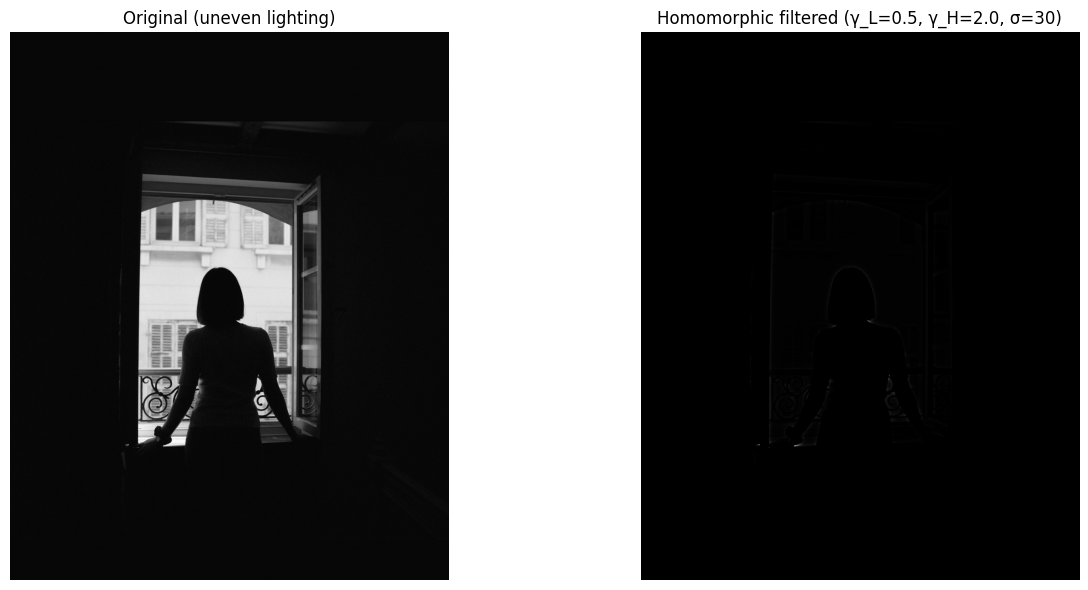

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(q12_im, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original (uneven lighting)'); ax[0].axis('off')
ax[1].imshow(g_norm, cmap='gray', vmin=0, vmax=255); ax[1].set_title(f'Homomorphic filtered (γ_L={gamma_low}, γ_H={gamma_high}, σ={sigma})'); ax[1].axis('off')
plt.tight_layout()
plt.show()

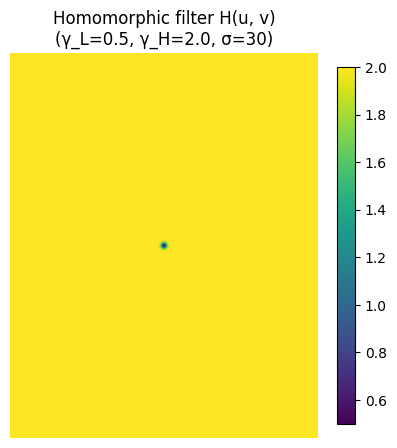

In [14]:
plt.figure(figsize=(5, 5))
plt.imshow(H, cmap='viridis')
plt.title(f'Homomorphic filter H(u, v)\n(γ_L={gamma_low}, γ_H={gamma_high}, σ={sigma})')
plt.colorbar(fraction=0.046)
plt.axis('off')
plt.show()

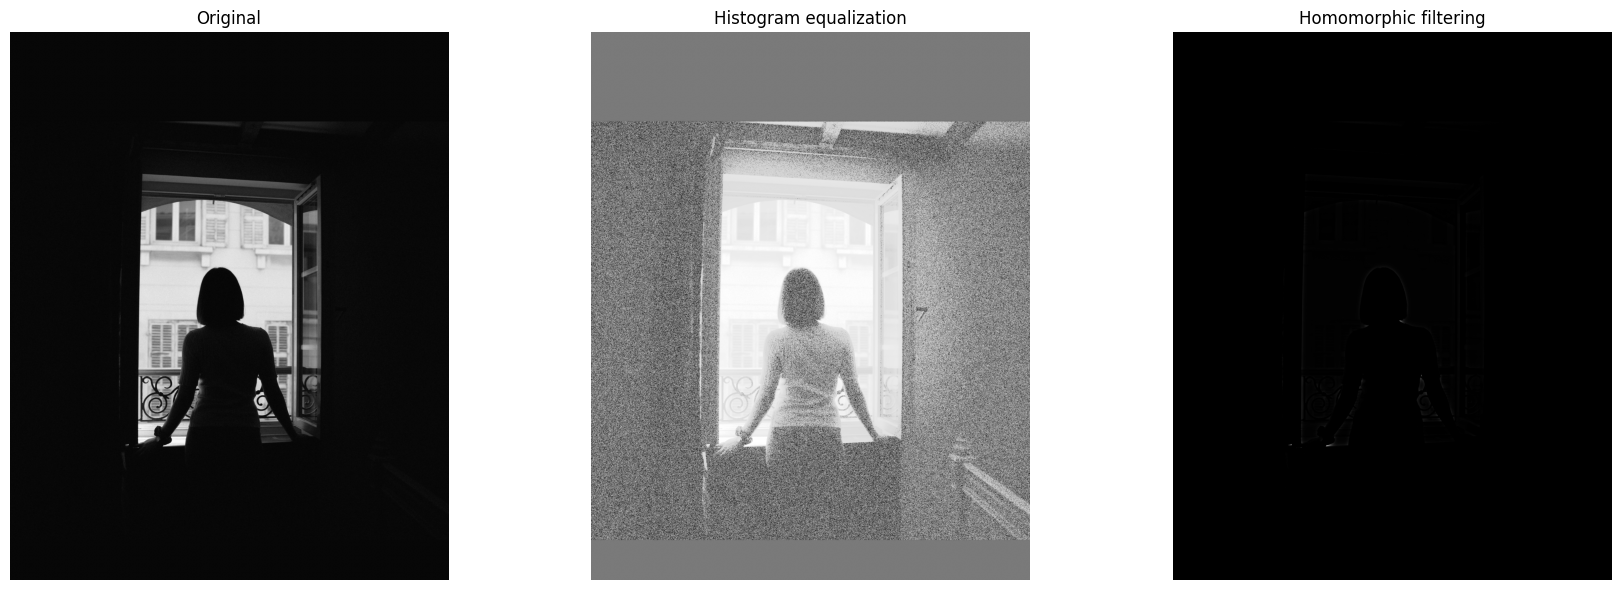

In [15]:
# Also run histogram equalization for comparison
g_histeq = cv.equalizeHist(q12_im)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(q12_im,   cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original');                 ax[0].axis('off')
ax[1].imshow(g_histeq, cmap='gray', vmin=0, vmax=255); ax[1].set_title('Histogram equalization');   ax[1].axis('off')
ax[2].imshow(g_norm,   cmap='gray', vmin=0, vmax=255); ax[2].set_title('Homomorphic filtering');    ax[2].axis('off')
plt.tight_layout()
plt.show()

### Observation

**Illumination correction.** The original image shows a severe illumination split — the room interior is very dark and the window area is bright. After applying homomorphic filtering, the dark region is visibly brightened so structures inside the room become visible, while the window region is not blown out. The filter has successfully suppressed the slow illumination gradient without losing detail.

**Contrast enhancement.** Fine details inside the dark room — the woman's silhouette, the door frame, elements on the wall — are now much more visible. Because the filter boosts high frequencies (reflectance), these details are amplified relative to the smoother illumination variation.

**Comparison with histogram equalization.** Both histogram equalization and homomorphic filtering brighten the dark region, but they work very differently:
- **Histogram equalization** redistributes pixel values globally. It does brighten the dark area, but it treats all pixels equally regardless of position — so it can over-amplify noise in the previously dark regions.
- **Homomorphic filtering** specifically targets the spatial pattern of uneven illumination. The result looks more natural and preserves the original scene's lighting character.

**Artifacts observed.** With the parameters used ($\gamma_L = 0.5$, $\gamma_H = 2.0$, $\sigma = 30$), there is slight noise amplification in the previously dark regions, since the filter is high-frequency-emphasizing and noise is naturally high-frequency. A subtle halo effect can also appear near the sharp edge between the dark room and bright window. These effects can be reduced by tuning the parameters (smaller $\gamma_H$, or larger $\sigma$).